<a href="https://colab.research.google.com/github/razokiyassine/Network-Intrusion-Detection/blob/main/TP1_Regression_Trafic_Reseau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = {
    "utilisateurs": [10, 15, 20, 25, 30, 35, 40, 45, 50, 55,
                     60, 65, 70, 75, 80, 85, 90, 95, 100, 105],
    "trafic": [20, 27, 35, 43, 50, 57, 66, 72, 80, 88,
               95, 103, 110, 118, 125, 133, 140, 149, 155, 165]
}
df = pd.DataFrame(data)
display(df)

,utilisateurs,trafic
0,10,20
1,15,27
2,20,35
3,25,43
4,30,50
5,35,57
6,40,66
7,45,72
8,50,80
9,55,88


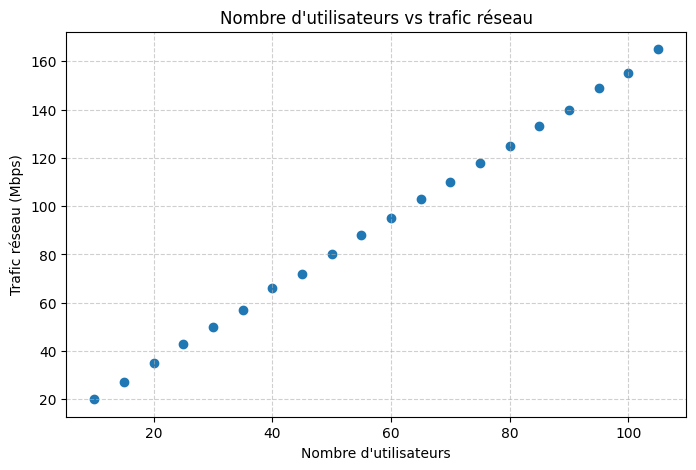

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["utilisateurs"], df["trafic"])
plt.xlabel("Nombre d'utilisateurs")
plt.ylabel("Trafic réseau (Mbps)")
plt.title("Nombre d'utilisateurs vs trafic réseau")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
X = df[["utilisateurs"]]
y = df["trafic"]
display(X.head())
display(y.head())

,utilisateurs
0,10
1,15
2,20
3,25
4,30


,trafic
0,20
1,27
2,35
3,43
4,50


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)
print("Données d'entraînement :", len(X_train))
print("Données de test :", len(X_test))

Données d'entraînement : 16
Données de test : 4


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Modèle entraîné.")

Modèle entraîné.


In [ ]:
beta0 = model.intercept_
beta1 = model.coef_[0]
print("β0 (intercept) =", beta0)
print("β1 (pente) =", beta1)
print(f"Équation : ŷ = {beta0:.2f} + {beta1:.2f}x")

β0 (intercept) = 4.672900015080685
β1 (pente) = 1.5103001055647716
Équation : ŷ = 4.67 + 1.51x


In [ ]:
y_pred = model.predict(X_test)
resultats = pd.DataFrame({
    "Utilisateurs": X_test["utilisateurs"].values,
    "Trafic réel": y_test.values,
    "Trafic prédit": y_pred
})
display(resultats)

,Utilisateurs,Trafic réel,Trafic prédit
0,10,20,19.775901
1,95,149,148.151410
2,85,133,133.048409
3,15,27,27.327402


In [ ]:
resultats["Résidu"] = (
    resultats["Trafic réel"] - resultats["Trafic prédit"]
)
display(resultats)

,Utilisateurs,Trafic réel,Trafic prédit,Résidu
0,10,20,19.775901,0.224099
1,95,149,148.151410,0.848590
2,85,133,133.048409,-0.048409
3,15,27,27.327402,-0.327402


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("R² :", r2)

MAE : 0.36212486804404787
MSE : 0.21996512020959738
R² : 0.9999369671008623


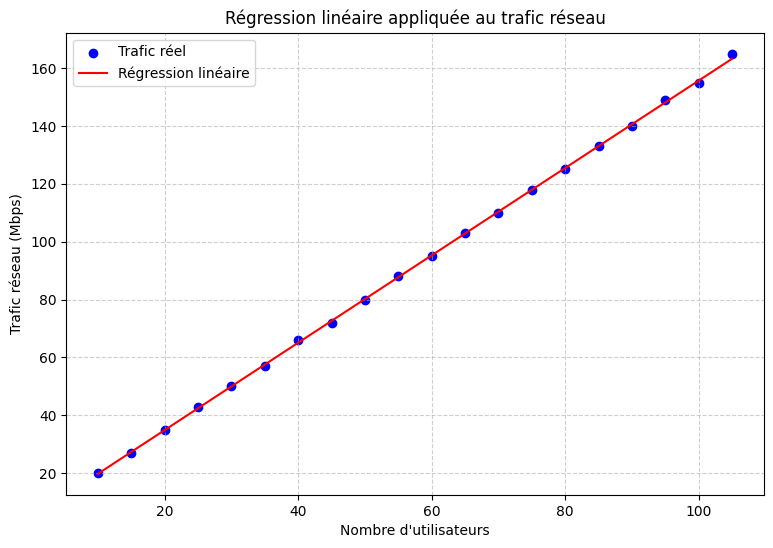

In [ ]:
X_plot = pd.DataFrame({
    "utilisateurs": np.linspace(
        df["utilisateurs"].min(),
        df["utilisateurs"].max(),
        100
    )
})
y_plot = model.predict(X_plot)
plt.figure(figsize=(9,6))
plt.scatter(df["utilisateurs"], df["trafic"], label="Trafic réel", color="blue")
plt.plot(X_plot["utilisateurs"], y_plot, label="Régression linéaire", color="red")
plt.xlabel("Nombre d'utilisateurs")
plt.ylabel("Trafic réseau (Mbps)")
plt.title("Régression linéaire appliquée au trafic réseau")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
nouvelle_donnee = pd.DataFrame({
    "utilisateurs": [110]
})
trafic_attendu = model.predict(nouvelle_donnee)[0]
print(
    f"Pour 110 utilisateurs, le trafic attendu est "
    f"{trafic_attendu:.2f} Mbps."
)

Pour 110 utilisateurs, le trafic attendu est 170.81 Mbps.


In [ ]:
trafic_observe = 220
residu = trafic_observe - trafic_attendu
print("Trafic attendu :", round(trafic_attendu, 2), "Mbps")
print("Trafic observé :", trafic_observe, "Mbps")
print("Résidu :", round(residu, 2), "Mbps")

Trafic attendu : 170.81 Mbps
Trafic observé : 220 Mbps
Résidu : 49.19 Mbps


In [ ]:
seuil = 40   # seuil pédagogique arbitraire
if abs(residu) > seuil:
    print("⚠️ Écart important : observation à investiguer.")
else:
    print("✓ Écart dans la plage définie.")
print(
    "\nAttention : un écart important ne signifie pas "
    "automatiquement qu'il s'agit d'une cyberattaque."
)

⚠️ Écart important : observation à investiguer.

Attention : un écart important ne signifie pas automatiquement qu'il s'agit d'une cyberattaque.
